# TRAINING AND ASSESSING THE MODELS

For this notebook please make sure that in *./csv/datasets* there are the following files:
- csv/datasets/nifh_dataset.csv
- csv/datasets/nifh_dataset_simple_tr.csv
- csv/datasets/nifh_dataset_simple_tr_out.csv
- csv/datasets/nifh_dataset_scikit_0.csv
- csv/datasets/nifh_dataset_scikit_2.csv

## Libraries

In [1]:
import sys
print(sys.executable)

/home/tim/OneDrive/fedora/Documents/SEMESTER4/int/werkstudent/N2-fixers-in-the-ocean/.venv/bin/python


In [2]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as matplotlib
import seaborn as sns
import joblib as joblib
from sklearn.metrics import mean_absolute_error

## Column names are stored 

In [3]:
x_columns = ['O2', 'T', 'N', 'P', 'Fe', 'solar','N:P']
y_columns =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']

## Functions

We need to get the functions I use for plotting in all the files

In [4]:
from visualize import plotColsOnMap, histCols

In [5]:
def getData(feature, dataset):
    cleared = dataset.dropna(subset=(feature+x_columns))[x_columns+y_columns]

    imp_cols = feature+x_columns
    print("after getting data NaN count is: {0}".format(cleared[imp_cols].isnull().sum().sum()))
    return cleared

In order to make testing different models easier I created a function for that purpose. 

In [6]:
from sklearn.metrics import root_mean_squared_error

def train_model(model, X_train, y_train, model_name="-"):
    #we train the model
    model.fit(X_train, y_train)

    #get the preictions
    predictions = model.predict(X_train)

    error_rate = root_mean_squared_error(y_train, predictions)
    print("Model {0} achieved RMSE score of {1} on train dataset".format(model_name, error_rate))

    return error_rate

This is a simple model against which we can benchmark the results of other models and see if they perform better or not.

In [7]:
class DummyModel():
    value=None

    def __init__(self):
        self.value=None

    def fit(self, X_train, y_train):
        self.value = np.mean(y_train)

    def predict(self, X_train):
        return np.full(len(X_train), self.value)


## Loading transofrmers
In join_csv we created several transformers that need to be defines in this file as well as they are custom and thus can't be loaded from the library.

In [8]:
from training import SimpleTransformer, SecondTransformer

In [9]:
transformers = joblib.load("../model/transformers")

Apply inverse transformations if the data was transformed before training using scaler or mathematic formulas. Here it is important that the function always return a pandas dataframe with the column set identical to the original.

In [10]:
def transofrm_back(name,df):
    if "simple" in name:
        print("using a simple tr")
        return SimpleTransformer().inverse_transform(df)
    elif "second" in name:
        if "scaled" in name:
            df = pd.DataFrame(transformers["second_transform_scaler"].inverse_transform(df), columns=df.columns)
        return SecondTransformer().inverse_transform(df)
    elif "power" in name:
        print("power branch is called")
        transfored_arr = transformers["power_transf"].inverse_transform(df)
    elif "quantile" in name:
        print("quantile branch is called")
        transfored_arr = transformers["quantile_transf"].inverse_transform(df)
    else:
        print("raw branch")
        return df
    
    return pd.DataFrame(transfored_arr, columns=df.columns)


A model is scored on the training and test data while transforming it to the original scale in order to see how off from the actual value we land.

In [11]:
def score_model(model, data_x, data_y, dataset_name, feature, error_function = root_mean_squared_error):
    #we predict using the model
    predictions = model.predict(data_x)
    predictions_df = data_x.copy()
    #we need to also have the original value
    score_df = pd.concat([data_x.copy(),data_y.copy()],axis=1)

    #for inverse transform to work the scalers in sci kit learn require the columns to be in the same order
    #as when fit was applied and be the same list
    for col in y_columns:
        if col == feature:
            predictions_df[feature] = predictions
        else:
            predictions_df[col]=data_y[col]            

    #after we format the data inverse transform can be applied. 
    tr_pr = transofrm_back(name=dataset_name, df=predictions_df)[feature]
    tr_sc = transofrm_back(name=dataset_name, df=score_df)[feature]

    return error_function(tr_sc, tr_pr)
    

In [12]:
def score_model_no_transf(model, data_x, data_y, feature, error_function = root_mean_squared_error):
    #we predict using the model
    predictions = model.predict(data_x)
    #actual values are in data_y
    true_values = data_y[feature]

    #the value is scored using the error function
    return error_function(true_values, predictions)


## Loading the datasets

We need to load the data into the notebook and store it in a dictionary

In [13]:
#this is how paths are stored and the names persist in the code
paths = {
    "raw_data": "../csv/datasets/nifh_dataset.csv",
    "simple_transform": "../csv/datasets/nifh_dataset_simple_tr.csv",
    "simple_transform_nobar": "../csv/datasets/nifh_dataset_simple_tr_nobar.csv",
    "second_transform": "../csv/datasets/nifh_dataset_second_tr.csv",
    "second_transform_scaled": "../csv/datasets/nifh_dataset_second_tr_scaled.csv",
    #"simple_transform without 'outliers'":"../csv/datasets/nifh_dataset_simple_tr_out.csv",
    "power_transf": "../csv/datasets/nifh_dataset_power_transf.csv",
    "quantile_transf": "../csv/datasets/nifh_dataset_quantile_transf.csv"
}

#here we store the pandas dataframes before splitting
datasets = dict()

#we open and store the csv files
for dset_name, path in paths.items():
    datasets[dset_name] = pd.read_csv(path)[x_columns+y_columns]

In [14]:
for dset_name, dataset in datasets.items():
    print("DATASET: {0}".format(dset_name))
    print(dataset.info())

DATASET: raw_data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30615 entries, 0 to 30614
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2                                         26960 non-null  float64
 1   T                                          26960 non-null  float64
 2   N                                          26960 non-null  float64
 3   P                                          26960 non-null  float64
 4   Fe                                         26960 non-null  float64
 5   solar                                      26960 non-null  float64
 6   N:P                                        26960 non-null  float64
 7   Trichodesmium nifH Gene (x106 copies m-3)  26640 non-null  float64
 8   UCYN-A nifH Gene (x106 copies m-3)         25185 non-null  float64
 9   UCYN-B nifH Gene (x106 copies m-3)         22802 non-null  float64
dtypes: f

## Displaying data
I want to show the initial distributions as it can be useful when interpreting results.

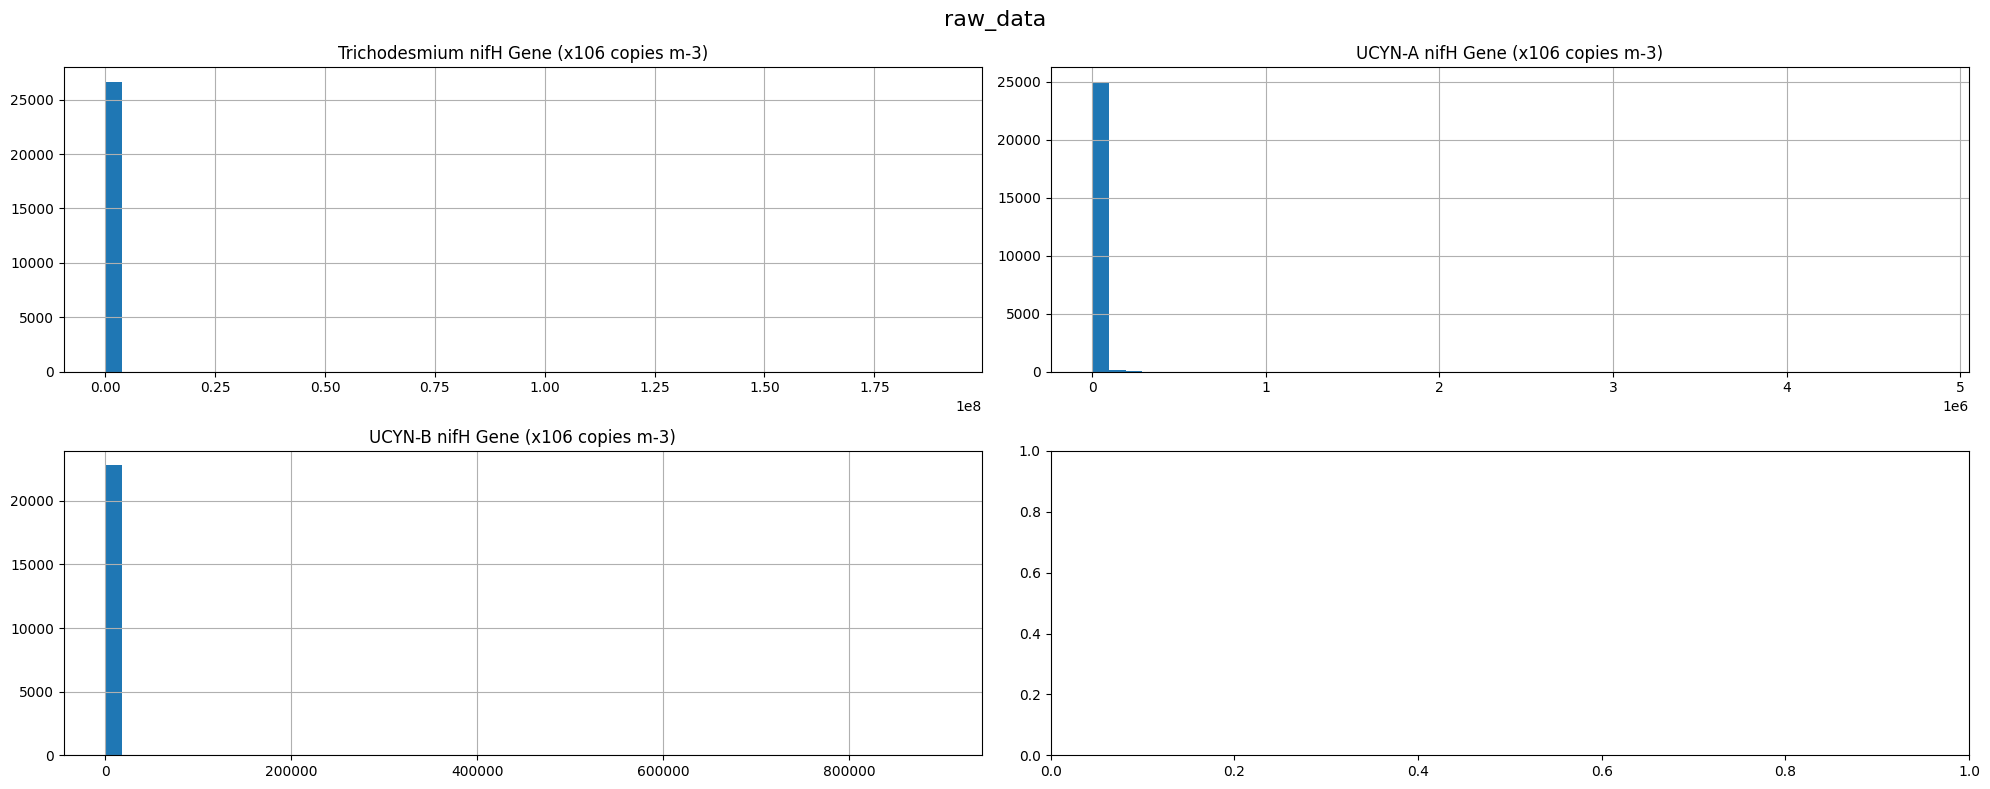

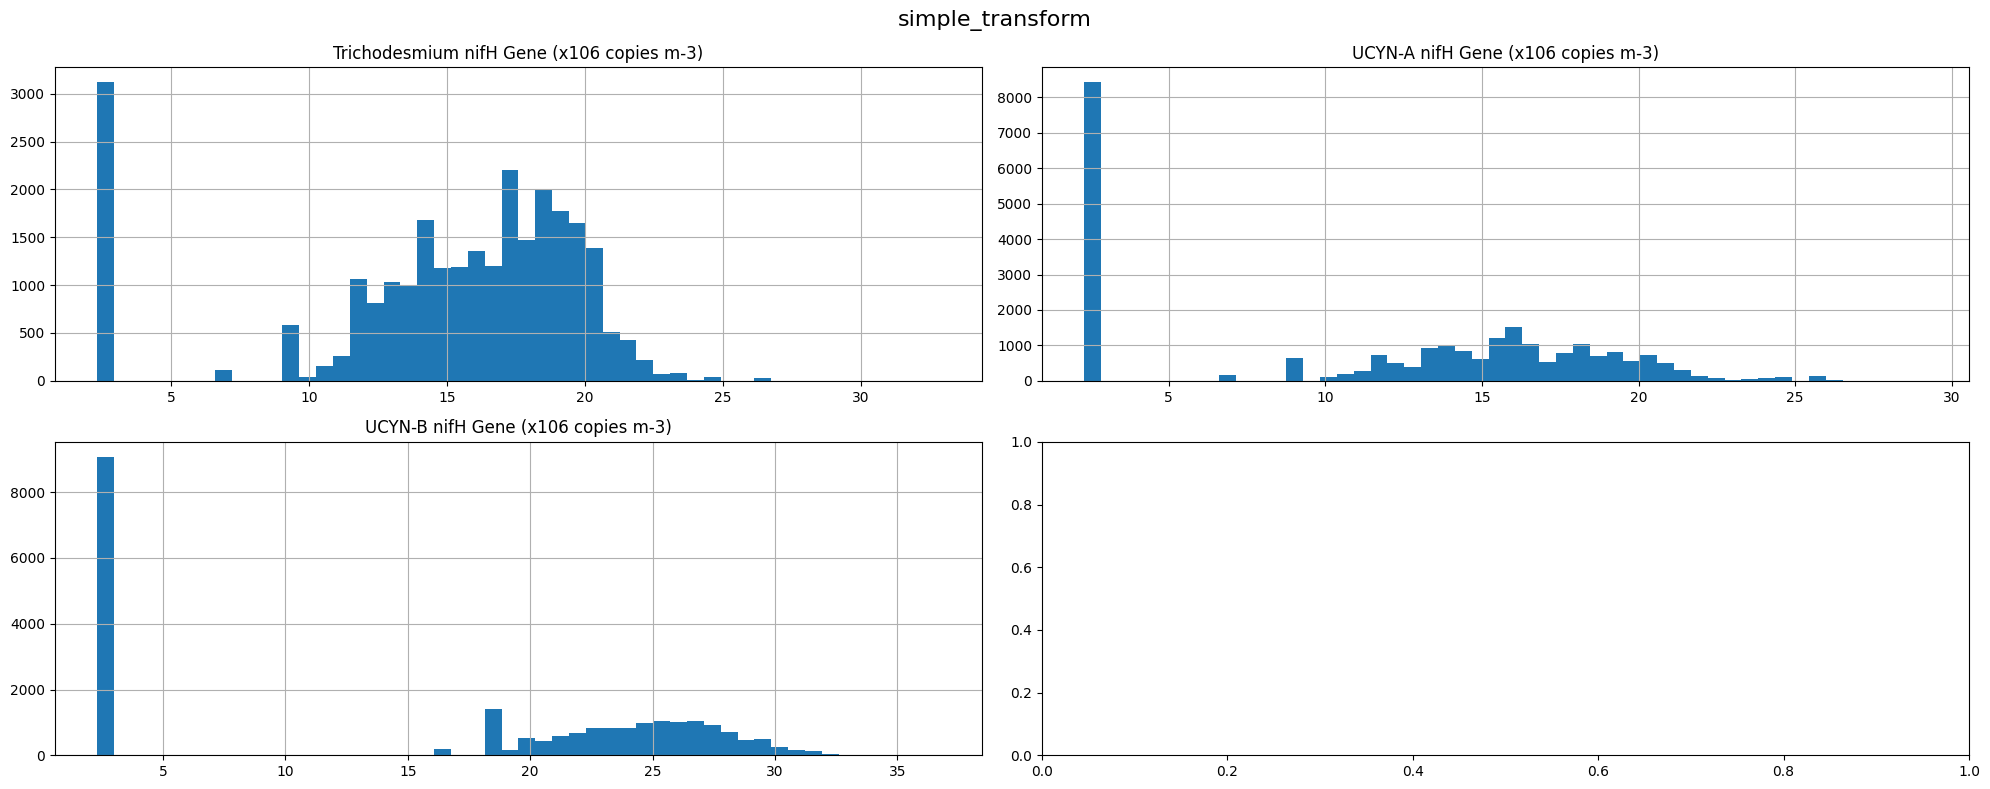

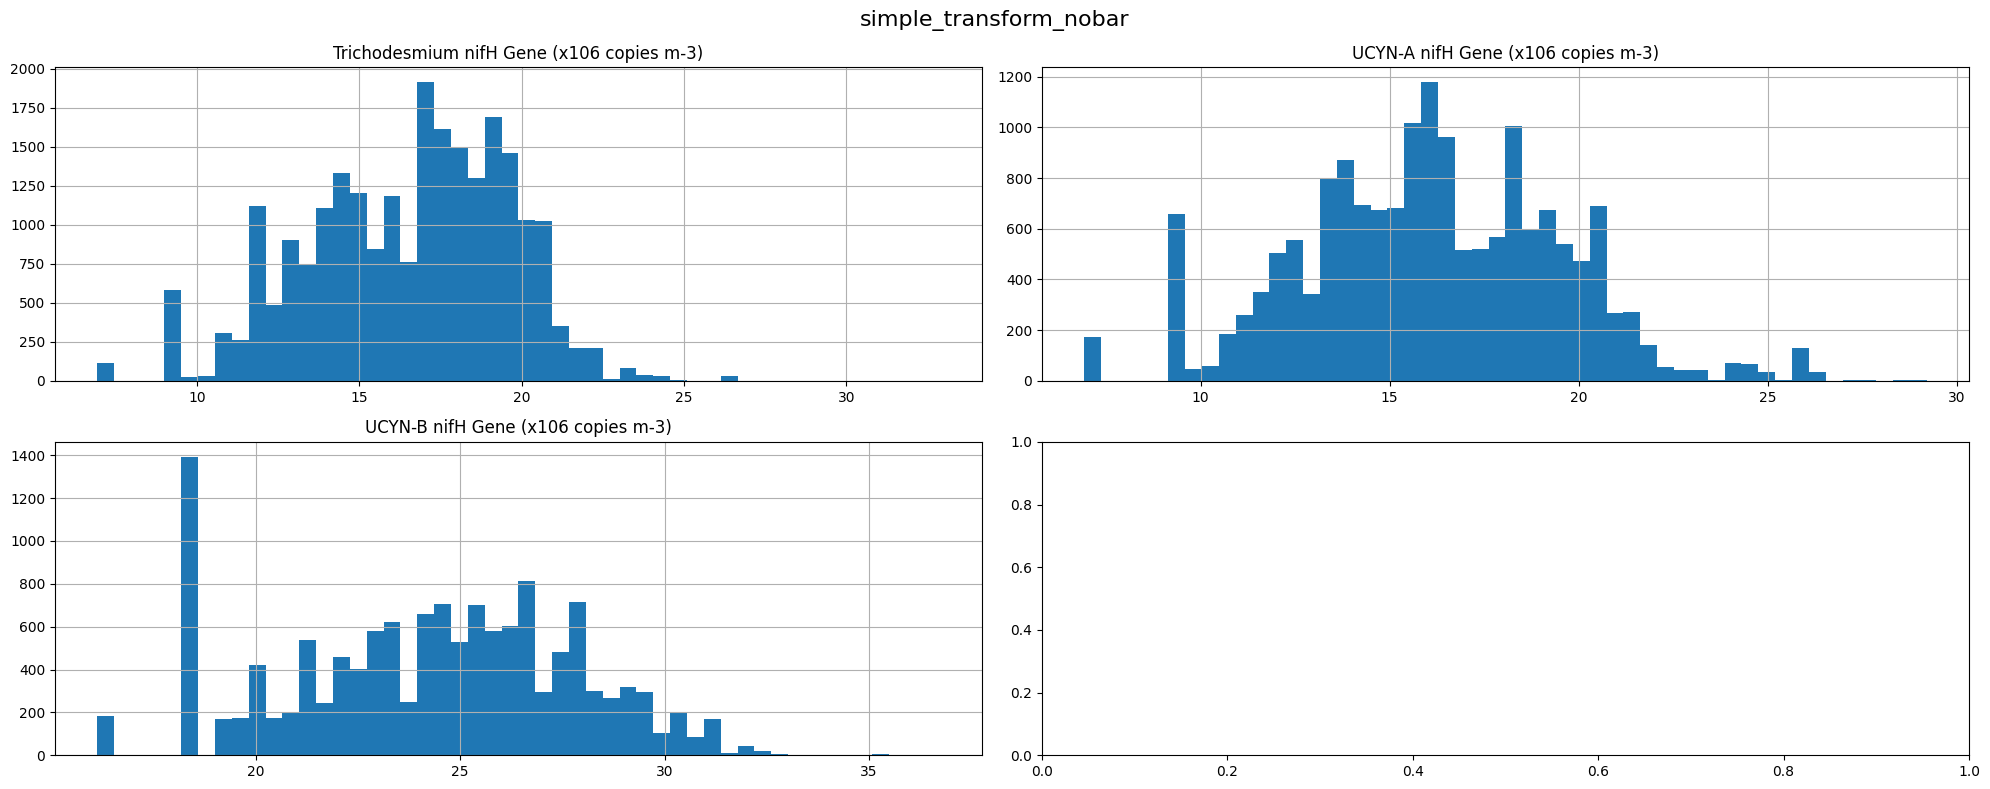

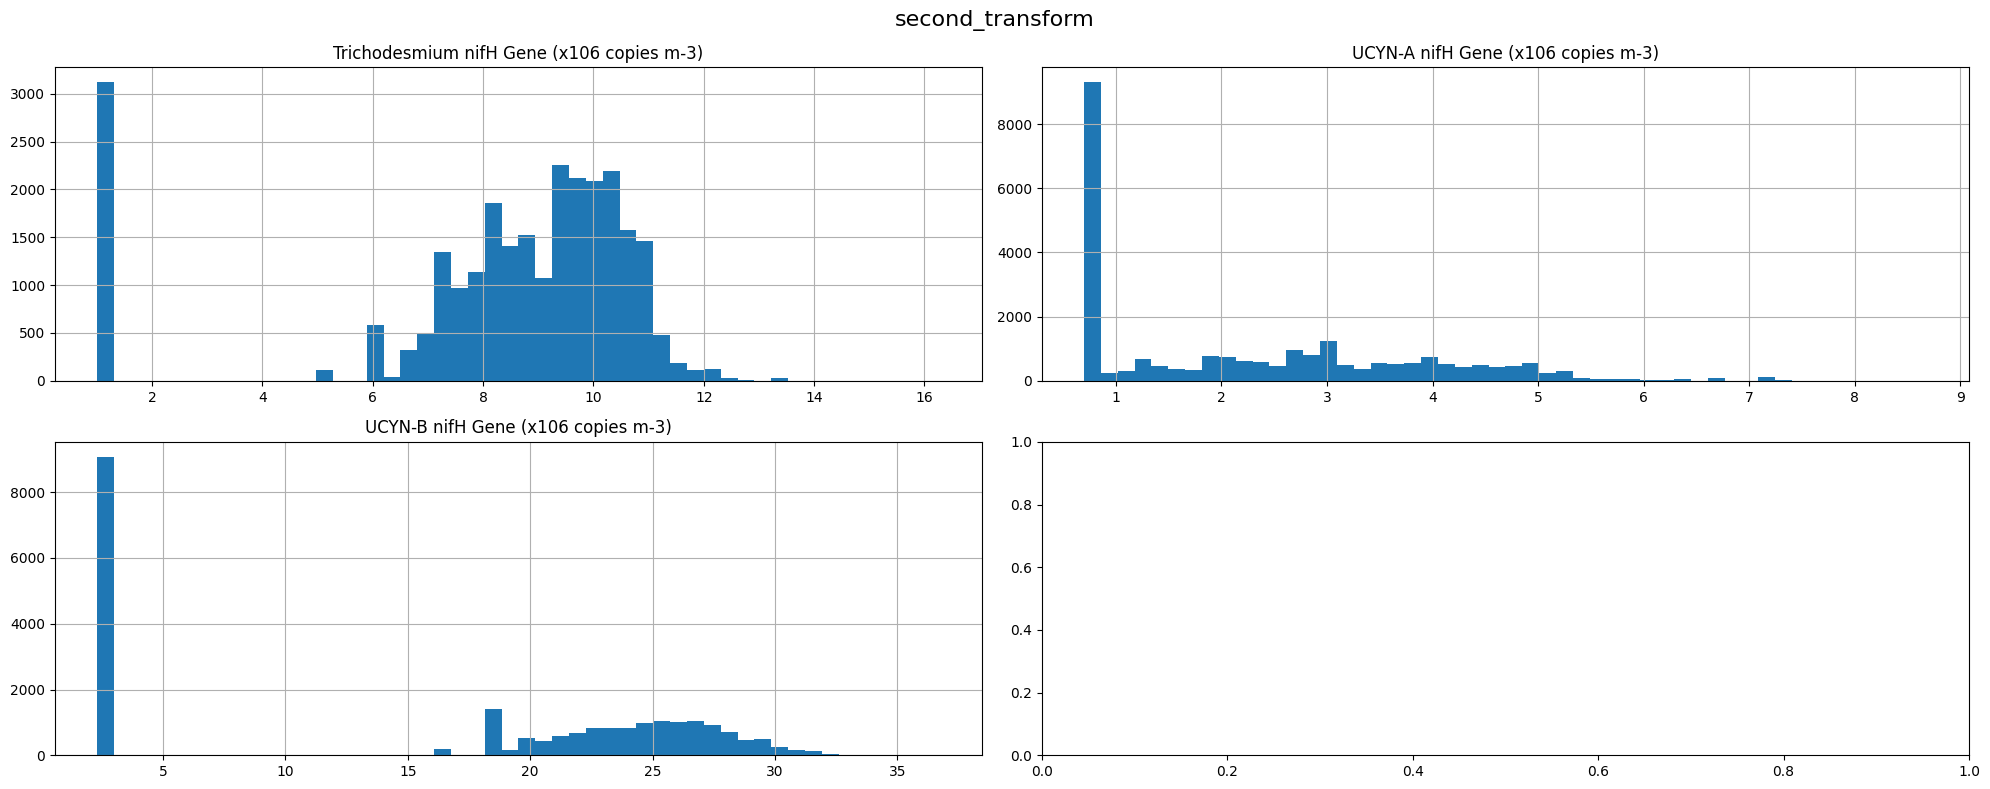

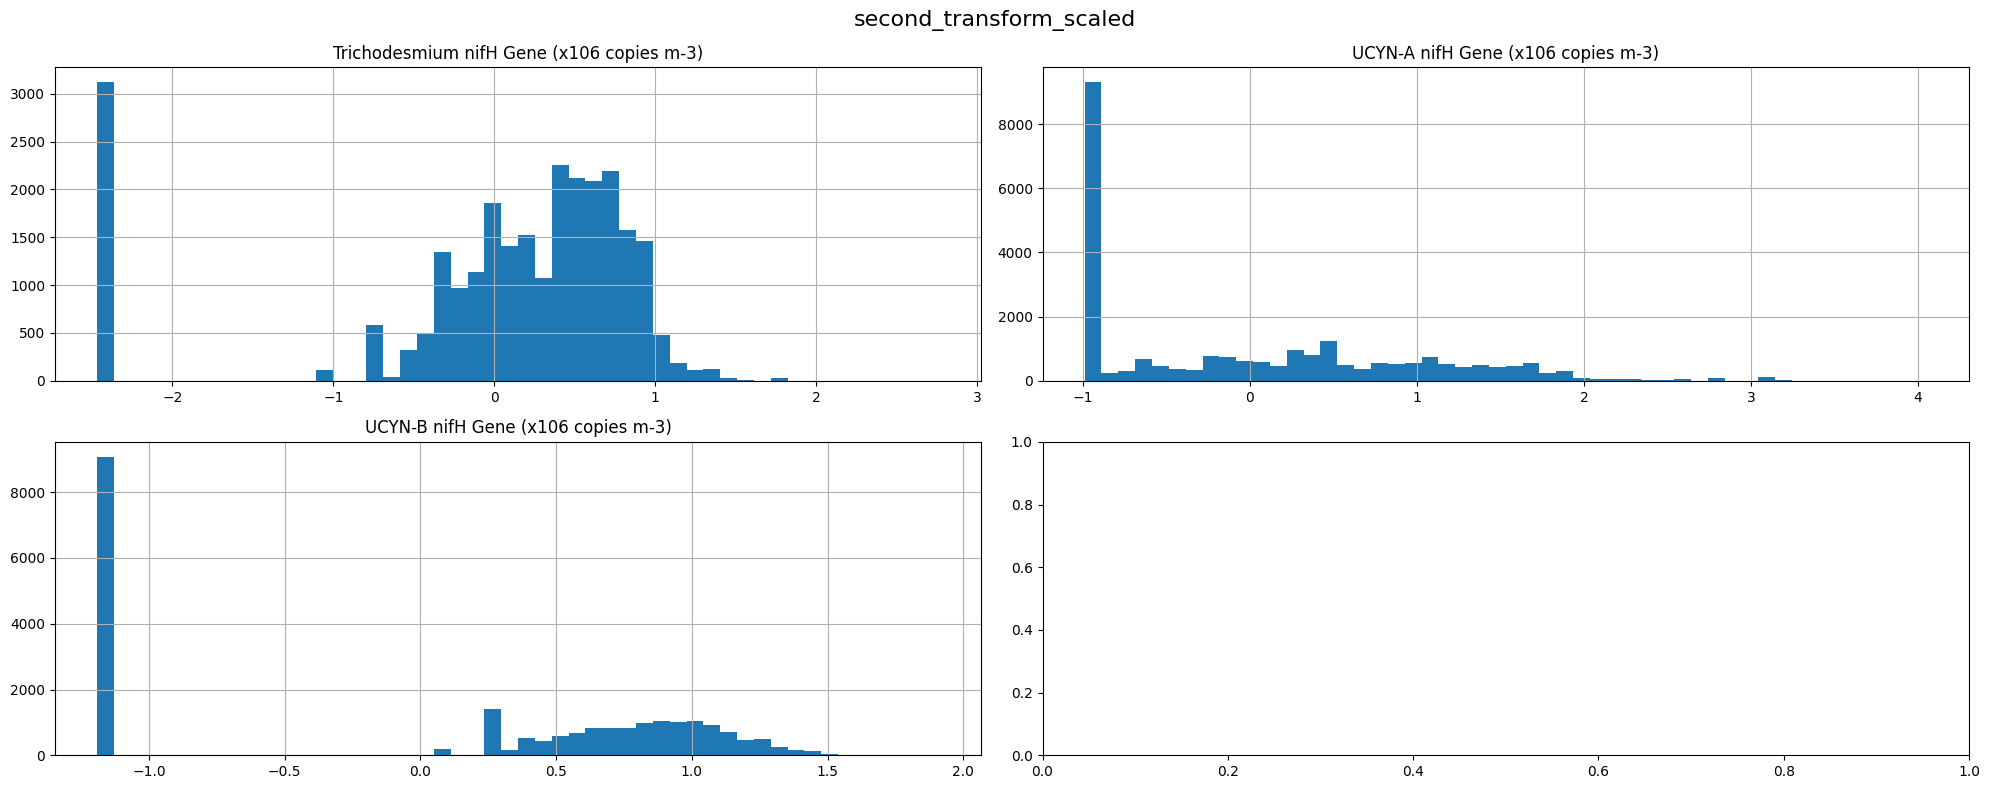

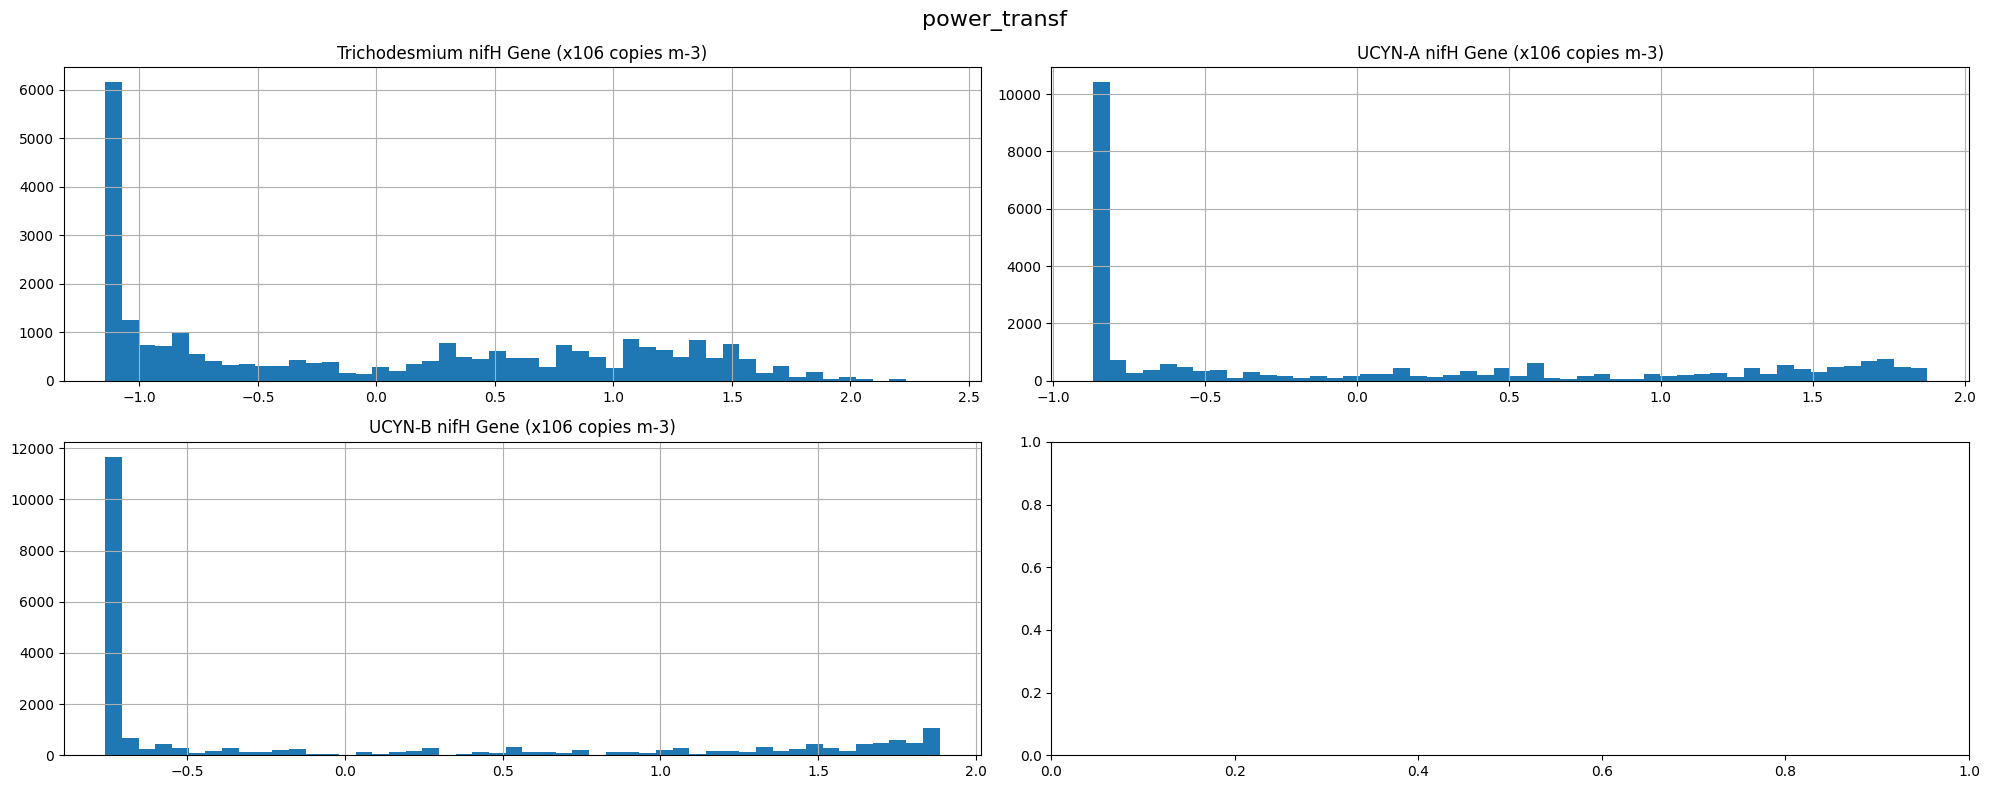

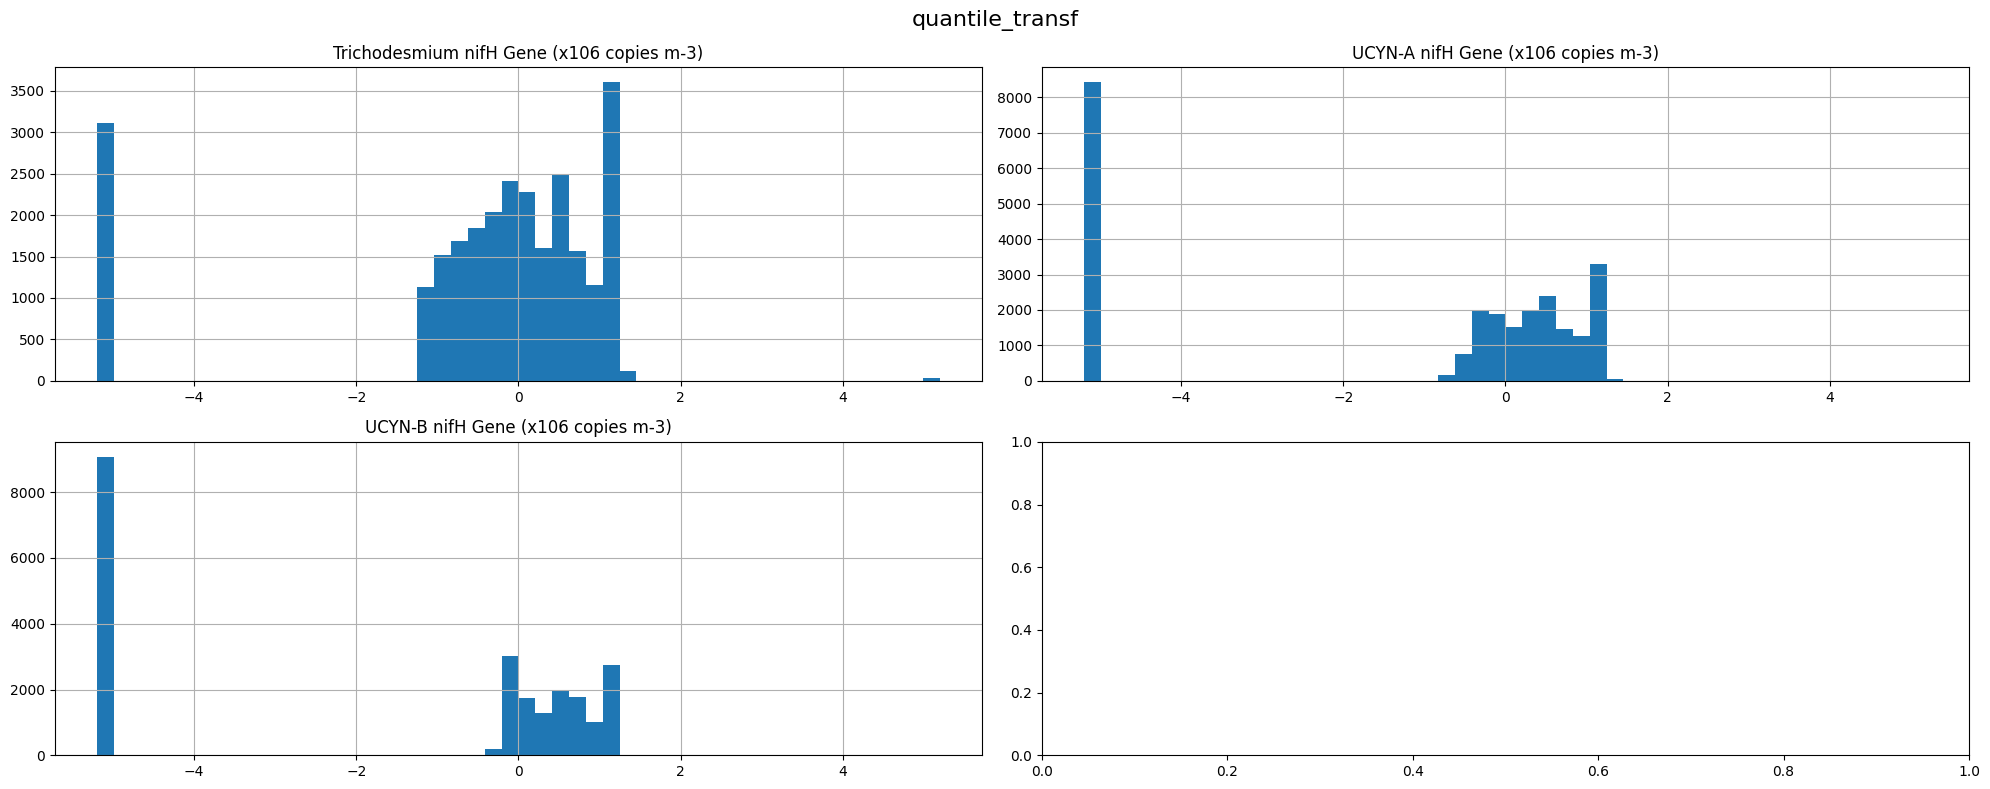

In [15]:
for dset_name, dataset in datasets.items():
    histCols(y_columns, dataset, suptitle=dset_name)

## Train test split

In order to verify that the data is actually generalizable and that the model can preditct on data it has never seen before we need to test it on such data that we set aside before training.

The data structure is the following:

```
training data:
{                                                         
    "name": {                                        
        "feature":{X_train, X_test, y_train, y_test}    
        "feature1":{X_train, X_test, y_train, y_test}   
        "feature2":{X_train, X_test, y_train, y_test}   
    }                                                   
    "name2": {                                          
        ...                                             
    }                                                      
}                                                       
```

In [ ]:
from sklearn.model_selection import train_test_split

training_data = dict()

for dset_name, dataset in datasets.items():
    training_data[dset_name]=dict()
    for feature in y_columns:
        #we filter the data by the feature before splitting
        temp_ds = getData([feature], dataset)
        X_train, X_test, y_train, y_test = train_test_split(temp_ds[x_columns], temp_ds[y_columns], test_size=0.2, random_state=42)

        #for all models the presence of null values is not allowed thus this verifies that this is the case
        if X_train.isnull().sum().sum() > 0:
            raise ValueError("X train contains null for ds:{0} feature: {1}".format(dset_name, feature))
        if X_test.isnull().sum().sum() >0:
            raise ValueError("X test contains null for ds:{0} feature: {1}".format(dset_name, feature))
        if y_train[feature].isnull().sum().sum() >0:
            raise ValueError("y train contains null for ds:{0} feature: {1} count: {2}".format(dset_name, feature,y_train.isnull().sum().sum()))
        if y_test[feature].isnull().sum().sum() >0:
            raise ValueError("y test contains null for ds:{0} feature: {1}".format(dset_name, feature))

        #we store the split data
        temp_dict = {
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test
        }

        #add results to the dictionary
        training_data[dset_name][feature] = temp_dict

after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0
after getting data NaN count is: 0


## Storing test results
In order to compare, store and visualize testing results we need a pandas dataframe

In [17]:
test_scores = pd.DataFrame(columns=["dataset name", "feature", "model","train_score","test_score","test_score_no_transf"])

## Functions for testing different models

Training a given model on all datasets and storing the results in a common dataframe.

In [18]:
def try_model_on_all(model, model_name):
    for name in paths.keys():
        print("DATASET TEST: {0}".format(name))
        for feature in y_columns:
            print("FEATURE: {0}".format(feature))
            data = training_data[name][feature]
            X_train = data["X_train"]
            y_train = data["y_train"][feature]

            #model is trained
            train_model(model, X_train=X_train, y_train=y_train, model_name=model_name)

            train_score = score_model(model, X_train, data["y_train"], name, feature)
            test_score = score_model(model, data["X_test"], data["y_test"], name, feature)
            test_score_no_transf = score_model_no_transf(model, data["X_test"], data["y_test"], feature)

            print("")
            ## we save the final results:
            test_scores.loc[test_scores.shape[0]]=[name, feature, model_name, train_score, test_score, test_score_no_transf]

        print("")

## Training a baseline model

For a good baseline we can consider using linear regression and just taking the mean. Likely neither will be great, but that is the point. We want to see that better more suited models can achieve higher results.

In [19]:
model = DummyModel()
model_name ="dummy model"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 8330.086718075525 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 14634.331572976558 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 444.9165661959552 on train dataset
raw branch
raw branch
raw branch
raw branch


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 5.454025311452307 on train dataset
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model dummy model achieved RMSE score of 7.132335914115014 on train dataset
using 

## Trying out more models

In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model_name="Linear regression"

try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 8312.776067858842 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 14503.820597387998 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 432.1395338416248 on train dataset
raw branch
raw branch
raw branch
raw branch


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 5.10655141901963 on train dataset
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Linear regression achieved RMSE score of 6.7805540479

In [21]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=4)
model_name="Decision tree regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 6136.31175691465 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 10546.997660845529 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 297.6907851607639 on train dataset
raw branch
raw branch
raw branch
raw branch


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Decision tree regressor achieved RMSE score of 4.629269097557447 on train dataset
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Decision tree regressor achie

In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model_name="Random forest regressor"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 5838.598259043188 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 9542.867319670999 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 111.45899206731178 on train dataset
raw branch
raw branch
raw branch
raw branch


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor achieved RMSE score of 1.4954385911863946 on train dataset
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random forest regressor ach

In [23]:
''' Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RSME score: -3.056369177248422'''

model = RandomForestRegressor(random_state=42,max_depth=20 ,max_features="sqrt", min_samples_leaf=1, min_samples_split=2, n_estimators=200)
model_name="Random forest regressor tuned"
try_model_on_all(model, model_name)

DATASET TEST: raw_data
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor tuned achieved RMSE score of 5829.535287453407 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random forest regressor tuned achieved RMSE score of 9537.575681593124 on train dataset
raw branch
raw branch
raw branch
raw branch

FEATURE: UCYN-B nifH Gene (x106 copies m-3)
Model Random forest regressor tuned achieved RMSE score of 111.435006575608 on train dataset
raw branch
raw branch
raw branch
raw branch


DATASET TEST: simple_transform
FEATURE: Trichodesmium nifH Gene (x106 copies m-3)
Model Random forest regressor tuned achieved RMSE score of 1.49547027319851 on train dataset
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

FEATURE: UCYN-A nifH Gene (x106 copies m-3)
Model Random 

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=0)
model_name="Gradient boosting regressor"
#try_model_on_all(model, model_name)

## Visualizing the results

In [25]:
test_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   dataset name          105 non-null    object 
 1   feature               105 non-null    object 
 2   model                 105 non-null    object 
 3   train_score           105 non-null    float64
 4   test_score            105 non-null    float64
 5   test_score_no_transf  105 non-null    float64
dtypes: float64(3), object(3)
memory usage: 5.7+ KB


In [26]:
test_scores.head()

,dataset name,feature,model,train_score,test_score,test_score_no_transf
0,raw_data,Trichodesmium nifH Gene (x106 copies m-3),dummy model,8330.086718,11002.402720,11002.402720
1,raw_data,UCYN-A nifH Gene (x106 copies m-3),dummy model,14634.331573,16450.235391,16450.235391
2,raw_data,UCYN-B nifH Gene (x106 copies m-3),dummy model,444.916566,504.462657,504.462657
3,simple_transform,Trichodesmium nifH Gene (x106 copies m-3),dummy model,8351.221903,11027.381839,5.392006
4,simple_transform,UCYN-A nifH Gene (x106 copies m-3),dummy model,14724.815604,16547.909254,7.132938


### Graph analysis
After performing the training of different models we want to compare 2 things. Firstly, performance across different datasets and which one ususally yields the lowest error rates. And performance across different models and which one has the most potential to accurately predict the data.

For **comparison across datasets** error rates on different scales won't do as they don't translate into the same error rate on the initial scale. So, I showed how each dataset performs on the initial scale to which the prediction results are transformed after inference.

For **comparison across models** I think keeping the scale might be a good idea is the data on the initial scale is very skewed so it might not capture the ability of a model to learn from the data as accurately.

/tmp/ipykernel_1472/333665103.py:22: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
/tmp/ipykernel_1472/333665103.py:22: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
/tmp/ipykernel_1472/333665103.py:22: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


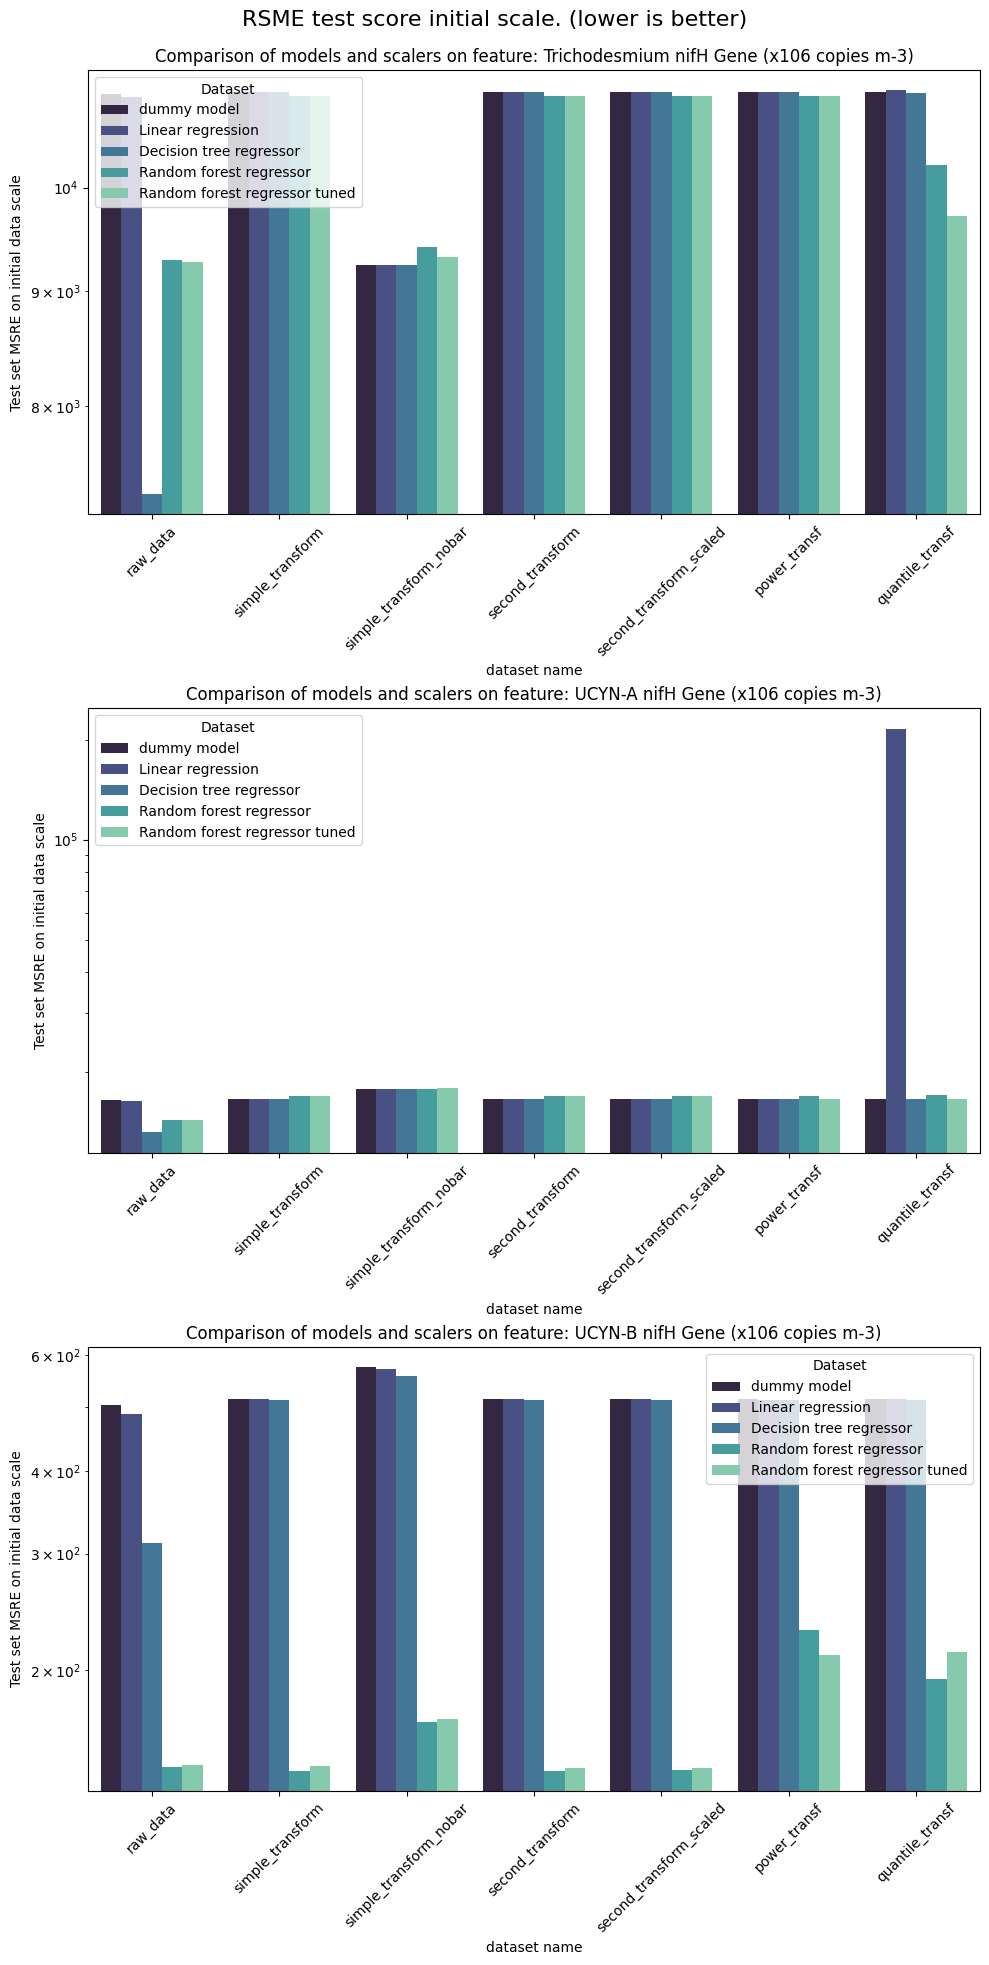

In [51]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))
axes = axes.flatten()

for i, feature in enumerate(y_columns):
    ax=axes[i]
    
    ##we plot a single feature
    subset = test_scores[test_scores['feature'] == feature]

    sns.barplot(
        data=subset,
        x='dataset name',
        y='test_score',
        hue='model',
        palette='mako',
        ax=ax
    )

    ax.set_title('Comparison of models and scalers on feature: {0}'.format(feature))
    ax.set_ylabel('Test set MSRE on initial data scale')
    ax.set_yscale('log')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Dataset')

plt.tight_layout()
fig.suptitle("RSME test score initial scale. (lower is better)",fontsize=16)
fig.subplots_adjust(top=0.95)
plt.show()

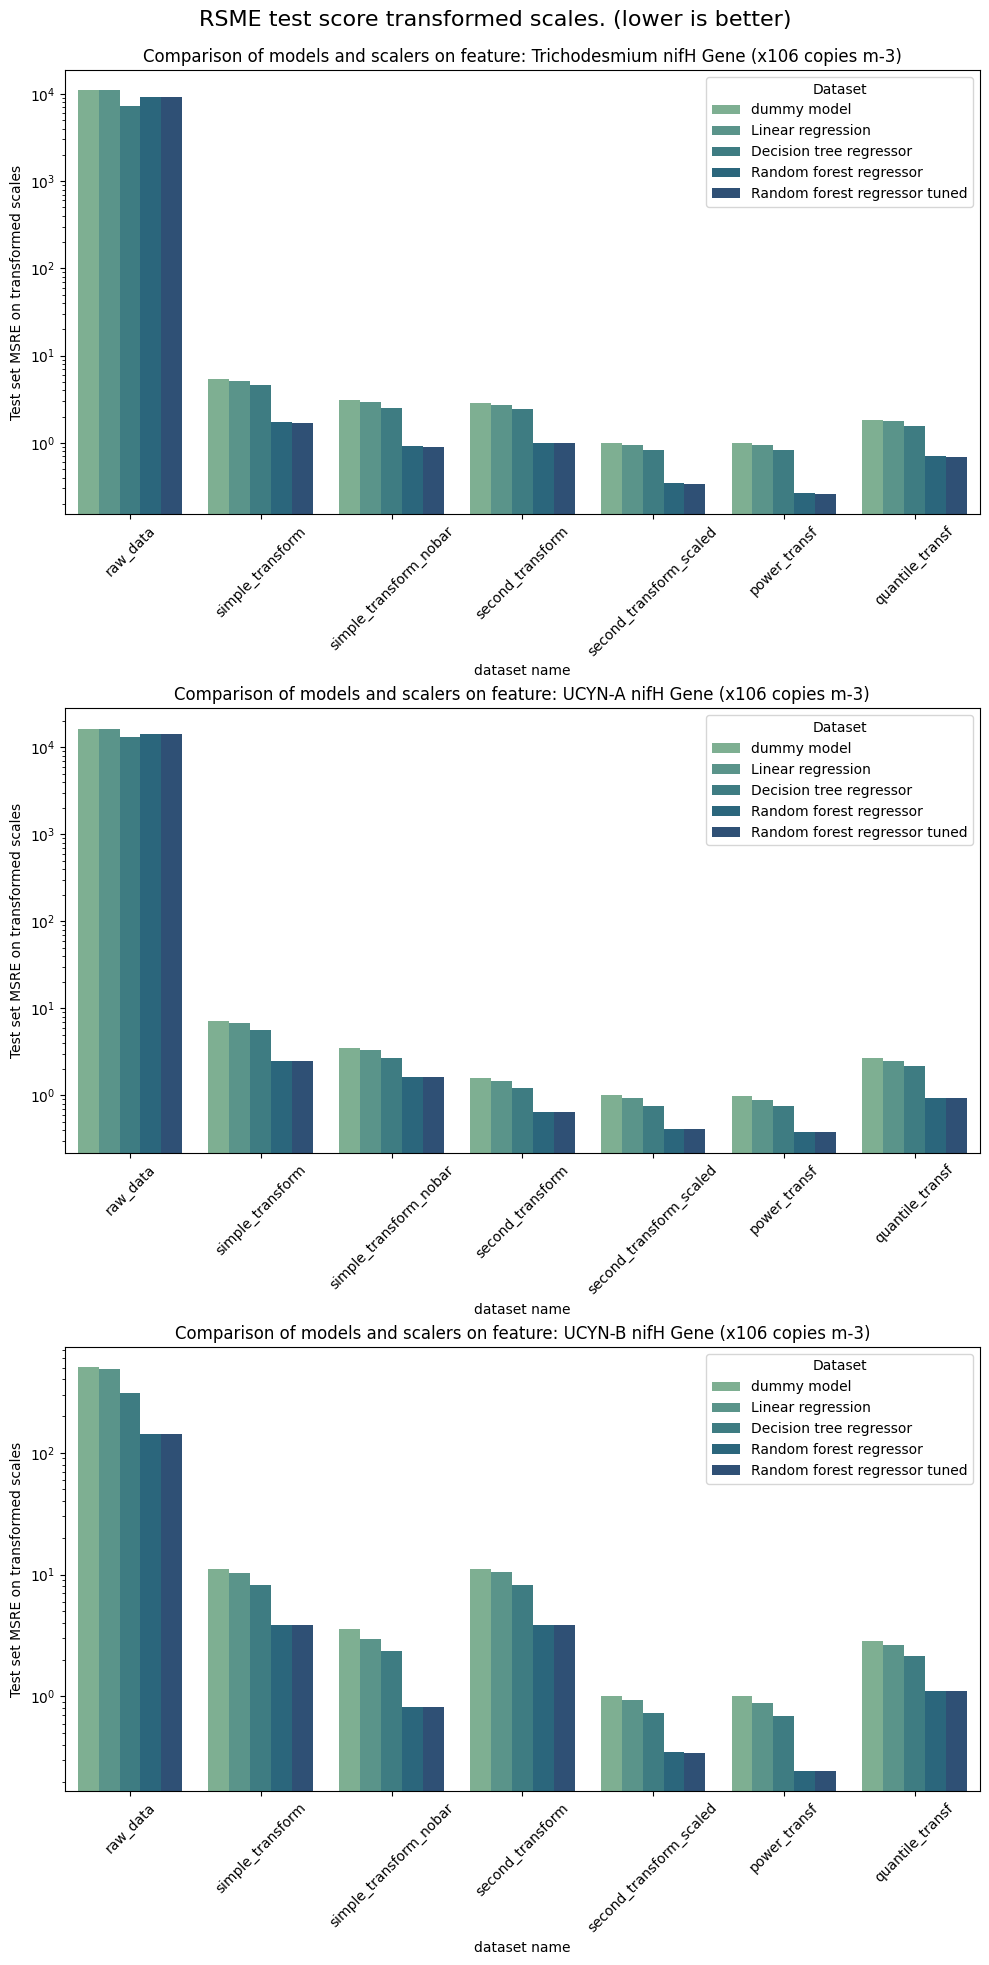

In [28]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))
axes = axes.flatten()

for i, feature in enumerate(y_columns):
    ax=axes[i]
    
    ##we plot a single feature
    subset = test_scores[test_scores['feature'] == feature]

    sns.barplot(
        data=subset,
        x='dataset name',
        y='test_score_no_transf',
        hue='model',
        palette='crest',
        ax=ax
    )

    ax.set_title('Comparison of models and scalers on feature: {0}'.format(feature))
    ax.set_ylabel('Test set MSRE on transformed scales')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Dataset')

plt.tight_layout()
fig.suptitle("RSME test score transformed scales. (lower is better)",fontsize=16)
fig.subplots_adjust(top=0.95)
plt.show()

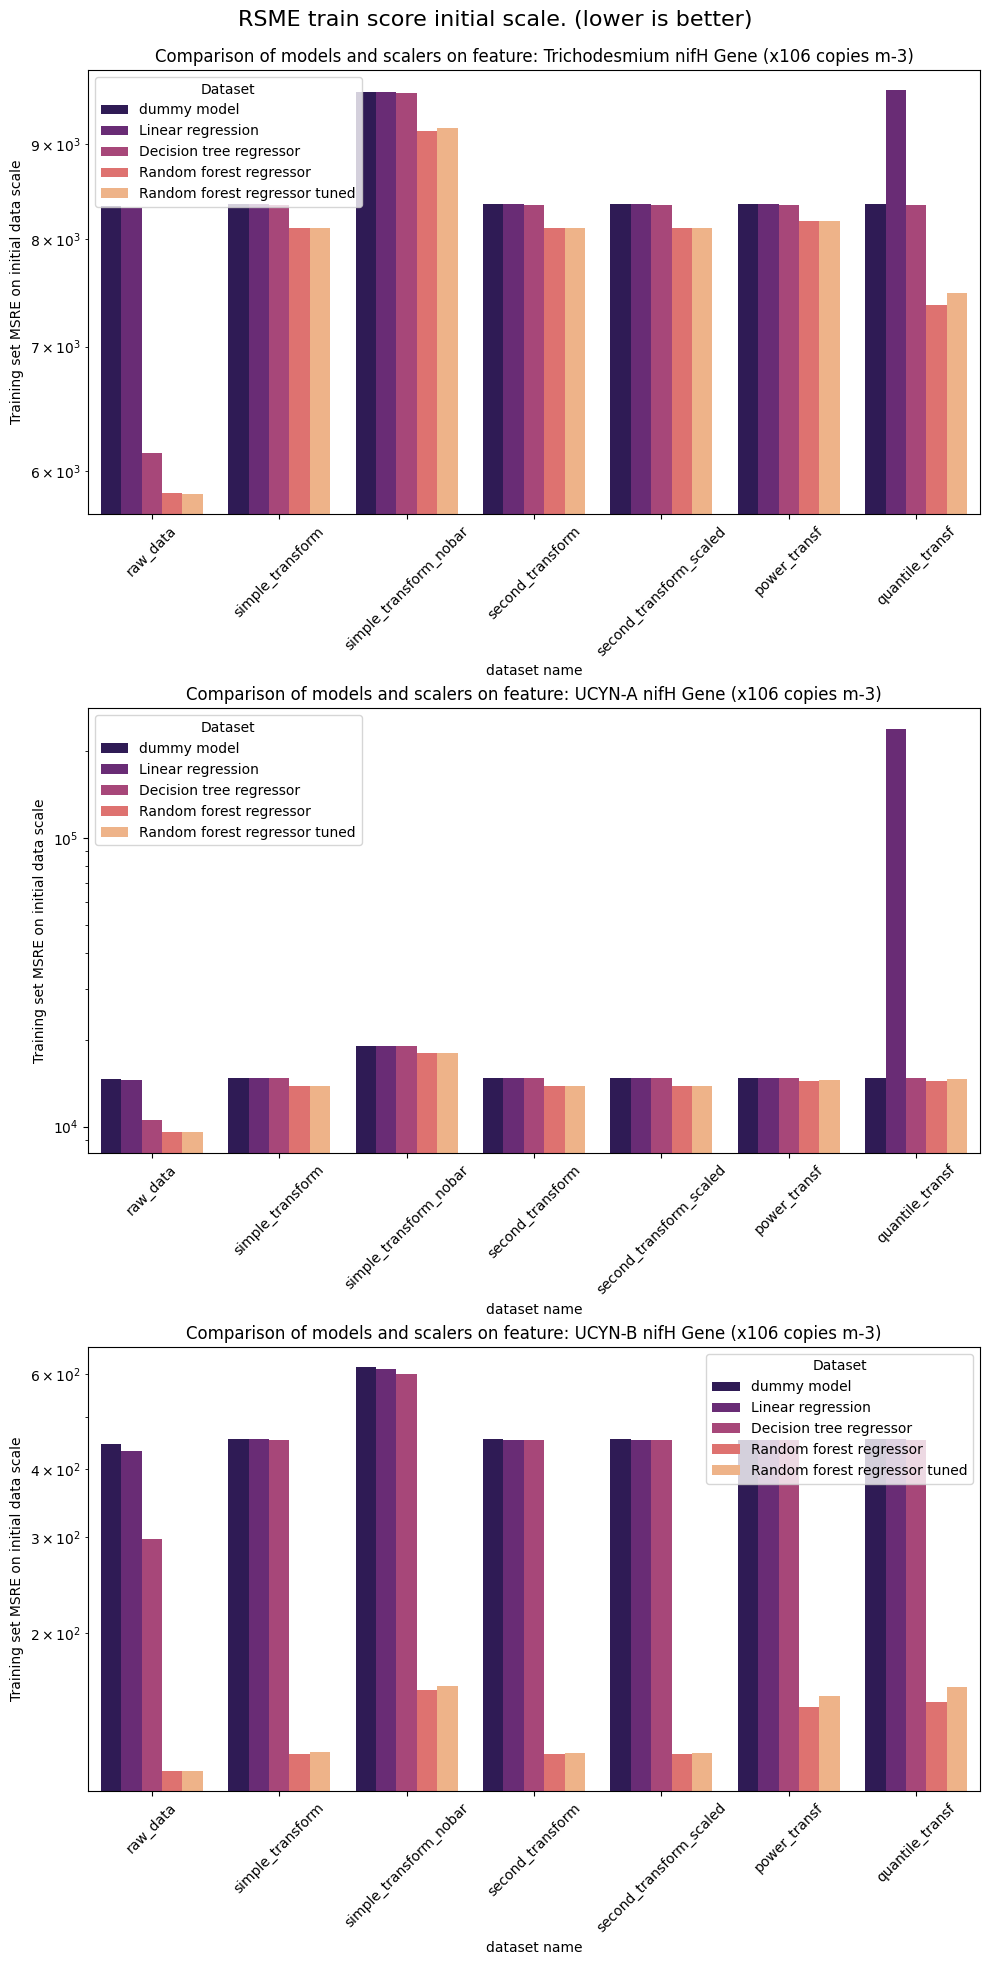

In [29]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 20))
axes = axes.flatten()

for i, feature in enumerate(y_columns):
    ax=axes[i]
    
    ##we plot a single feature
    subset = test_scores[test_scores['feature'] == feature]

    sns.barplot(
        data=subset,
        x='dataset name',
        y='train_score',
        hue='model',
        palette='magma',
        ax=ax
    )

    ax.set_title('Comparison of models and scalers on feature: {0}'.format(feature))
    ax.set_ylabel('Training set MSRE on initial data scale')
    ax.set_yscale('log')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Dataset')

plt.tight_layout()
fig.suptitle("RSME train score initial scale. (lower is better)",fontsize=16)
fig.subplots_adjust(top=0.95)
plt.show()

## Linear regression analysis

One of the tasks to me was to train a linear regression model and record/display the coefficients. So, this is what the next few cells do.

In [30]:
lin_set_name = "simple_transform_nobar"
data = training_data[dset_name]

coef_df = pd.DataFrame(columns=x_columns)

for feature in y_columns:
    #we pick the data related to the feature
    data_ft = data[feature]

    #the training data
    X_train = data_ft["X_train"]
    y_train = data_ft["y_train"][feature]

    model = LinearRegression().fit(X_train, y_train)
    coef = model.coef_
    row = coef_df.shape[0]
    
    coef_df.loc[row] =  coef

coef_df["feature"] = y_columns
df_melted = coef_df.melt(id_vars='feature', var_name='variable', value_name='value')

df_melted.head()

,feature,variable,value
0,Trichodesmium nifH Gene (x106 copies m-3),O2,0.499415
1,UCYN-A nifH Gene (x106 copies m-3),O2,0.047891
2,UCYN-B nifH Gene (x106 copies m-3),O2,-0.818671
3,Trichodesmium nifH Gene (x106 copies m-3),T,0.619911
4,UCYN-A nifH Gene (x106 copies m-3),T,-1.745896


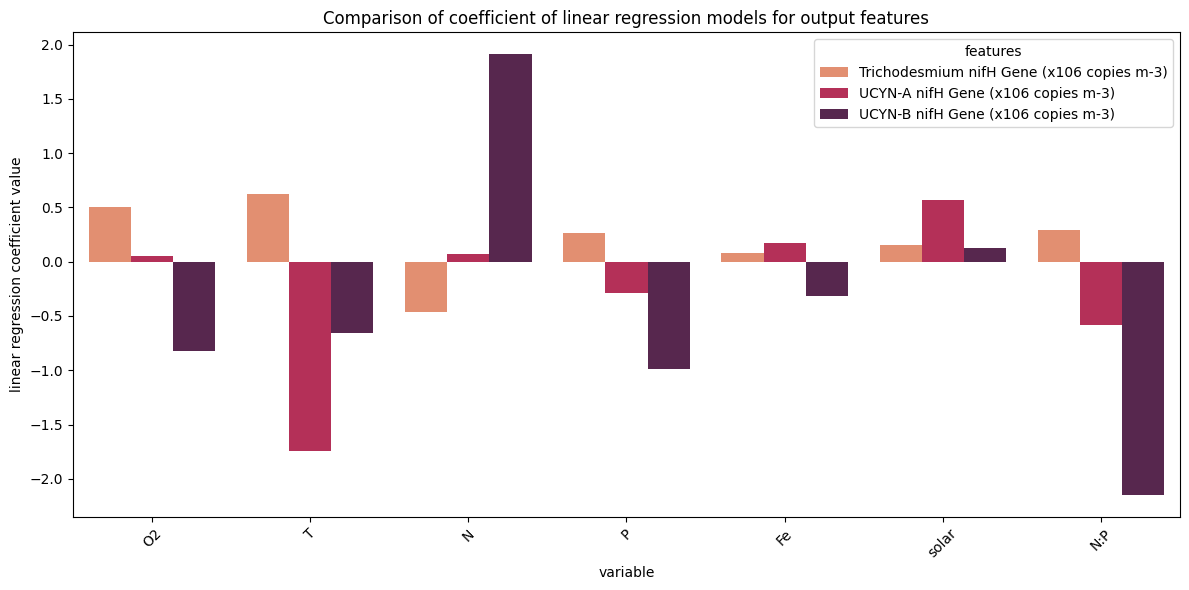

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted,
    x='variable',
    y='value',
    hue='feature',
    palette='rocket_r',
)

plt.title("Comparison of coefficient of linear regression models for output features")
plt.ylabel('linear regression coefficient value')
plt.tick_params(axis='x', rotation=45)
plt.legend(title='features')
plt.tight_layout()
plt.show()

## Conclusion

### Dataset(scaler-transform) choice:
So far the most crucial factor seems to be the dataset used. Despite the correlation suggesting one type of picutre, where UCYN should have the best predictions on scikit scalers, a simple transform set has the lowest error rates accross the board.


### Model choice:
It appears as though differences between different models aren't that great, but the rfr has by far the lowest erros everywhere. It should be noted here that not having a great difference regardless of the model might mean that due to data being so skewed predicting the average is a surprisingly good strategy for any model.


Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

dset_name = "simple_transform_nobar"
data = training_data[dset_name]
feature= y_columns[0]
data_ft = data[feature]

X_train = data_ft["X_train"]
y_train = data_ft["y_train"][feature]

# Base model
rfr = RandomForestRegressor(random_state=42)

# Parameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

#this part of the code will take a long time to run i recommend uncommentign only if needed
'''
grid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best RSME score:", grid_search.best_score_)
'''

'\ngrid_search = GridSearchCV(estimator=rfr, param_grid=param_grid,scoring=\'neg_root_mean_squared_error\', cv=5, n_jobs=-1, verbose=2)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\nprint("Best RSME score:", grid_search.best_score_)\n'

In order to choose differernt datasets for different features we can specify them in this dictionary

In [33]:
final_datasets = {
    "Trichodesmium nifH Gene (x106 copies m-3)": "simple_transform_nobar",
    "UCYN-A nifH Gene (x106 copies m-3)": "simple_transform_nobar",
    "UCYN-B nifH Gene (x106 copies m-3)": "simple_transform_nobar",
}

final_models_names = {
    "Trichodesmium nifH Gene (x106 copies m-3)": RandomForestRegressor(),
    "UCYN-A nifH Gene (x106 copies m-3)": RandomForestRegressor(),
    "UCYN-B nifH Gene (x106 copies m-3)": RandomForestRegressor()
}

data = dict()

for feature, ds_name in final_datasets.items():
    data[feature] = training_data[ds_name]

final_models = dict()



for feature in y_columns:
    #we pick the data related to the feature
    data_ft = data[feature][feature]

    #the training data
    X_train = data_ft["X_train"]
    y_train = data_ft["y_train"][feature]

    model = final_models_names[feature].fit(X_train, y_train)
    final_models[feature]=model

## Map projections
We obtained the prelimiary testing results. Now we can load back the data of the environmental variables and try to predict the ocean data for each feature. Here we use the final model set and project what the data should be according to the models on the rest of the globe.

In [ ]:
env_data = pd.read_csv("../csv/filled/env_data_lat_fill.csv")

env_data = env_data.dropna(subset=x_columns)

env_data_mask = env_data["DEPTH (m)"]<=5
env_data=env_data[env_data_mask]

coordinates = env_data[["LONGITUDE", "LATITUDE"]].copy()
env_data=env_data[x_columns]

#this is to make sure the scaler works
env_data_rows = env_data.shape[0]
for col in y_columns:
    env_data[col] = np.ones(env_data_rows)

env_data_dict = dict()

for feature in y_columns:
    dataset_name = final_datasets[feature]
    if dataset_name == "raw_data":
        env_data_array = env_data.copy()
    else:
        env_data_array = transformers[dataset_name].transform(env_data.copy())
    env_data_df = pd.DataFrame(env_data_array, columns=env_data.columns)[x_columns]

    env_data_dict[feature] = env_data_df

### Data is predicted based on environmental factors

In [35]:
predictions_df = pd.DataFrame()

#we predict the data and join back the coordinates
for feature in y_columns:
    predictions = final_models[feature].predict(env_data_dict[feature])
    predictions_df[feature]=predictions

### Inverse transform

In [36]:
predictions_df_invtr = pd.DataFrame()

for feature in y_columns:
    predictions_df_invtr_feat = transofrm_back(final_datasets[feature], pd.concat([env_data_dict[feature], predictions_df], axis=1))[feature]
    predictions_df_invtr[feature] = predictions_df_invtr_feat

predictions_df_invtr_cr = pd.concat([coordinates.copy(), predictions_df_invtr], axis=1)
predictions_df_invtr_cr.describe()

using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated


,LONGITUDE,LATITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,596488.000000,596488.000000,596488.000000,596488.000000,596488.000000
mean,-10.874673,-7.096901,124.558631,41.747154,25.044945
std,109.777733,43.388101,459.230460,167.483243,197.225009
min,-180.000000,-78.000000,0.003428,0.004272,0.001000
25%,-112.000000,-44.000000,12.675472,2.826896,0.353248
50%,-20.000000,-12.000000,54.956638,8.228180,0.544340
75%,84.000000,24.000000,109.219556,44.680114,2.026095
max,178.000000,90.000000,145360.834707,11435.098719,6405.929000


### Maps

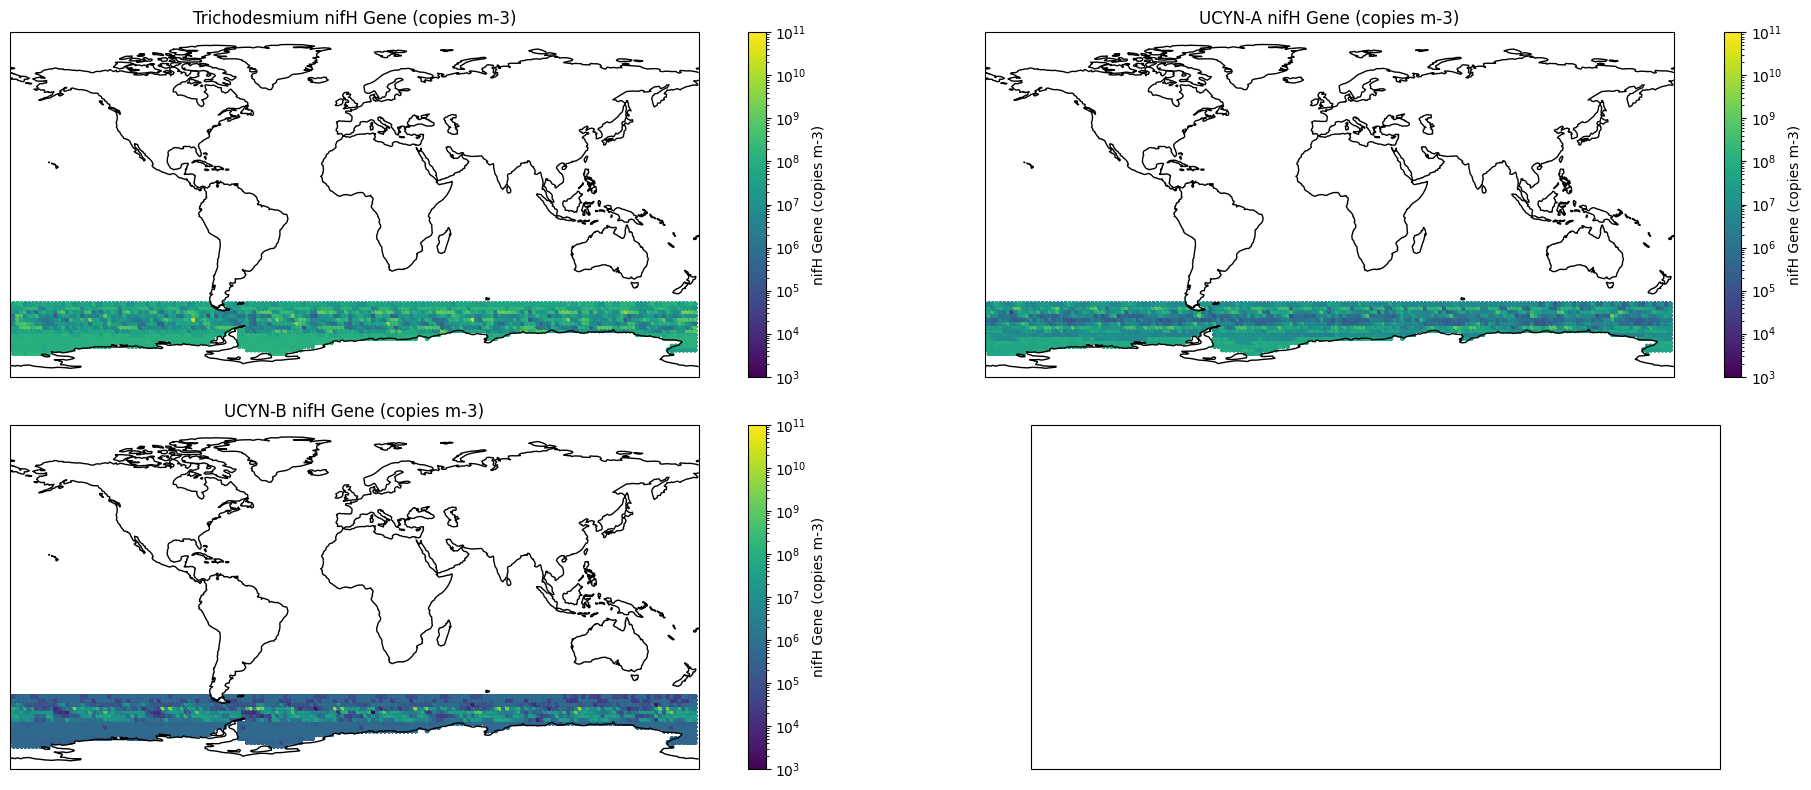

In [45]:
plotColsOnMap(y_columns, predictions_df_invtr_cr, True, 10**6)

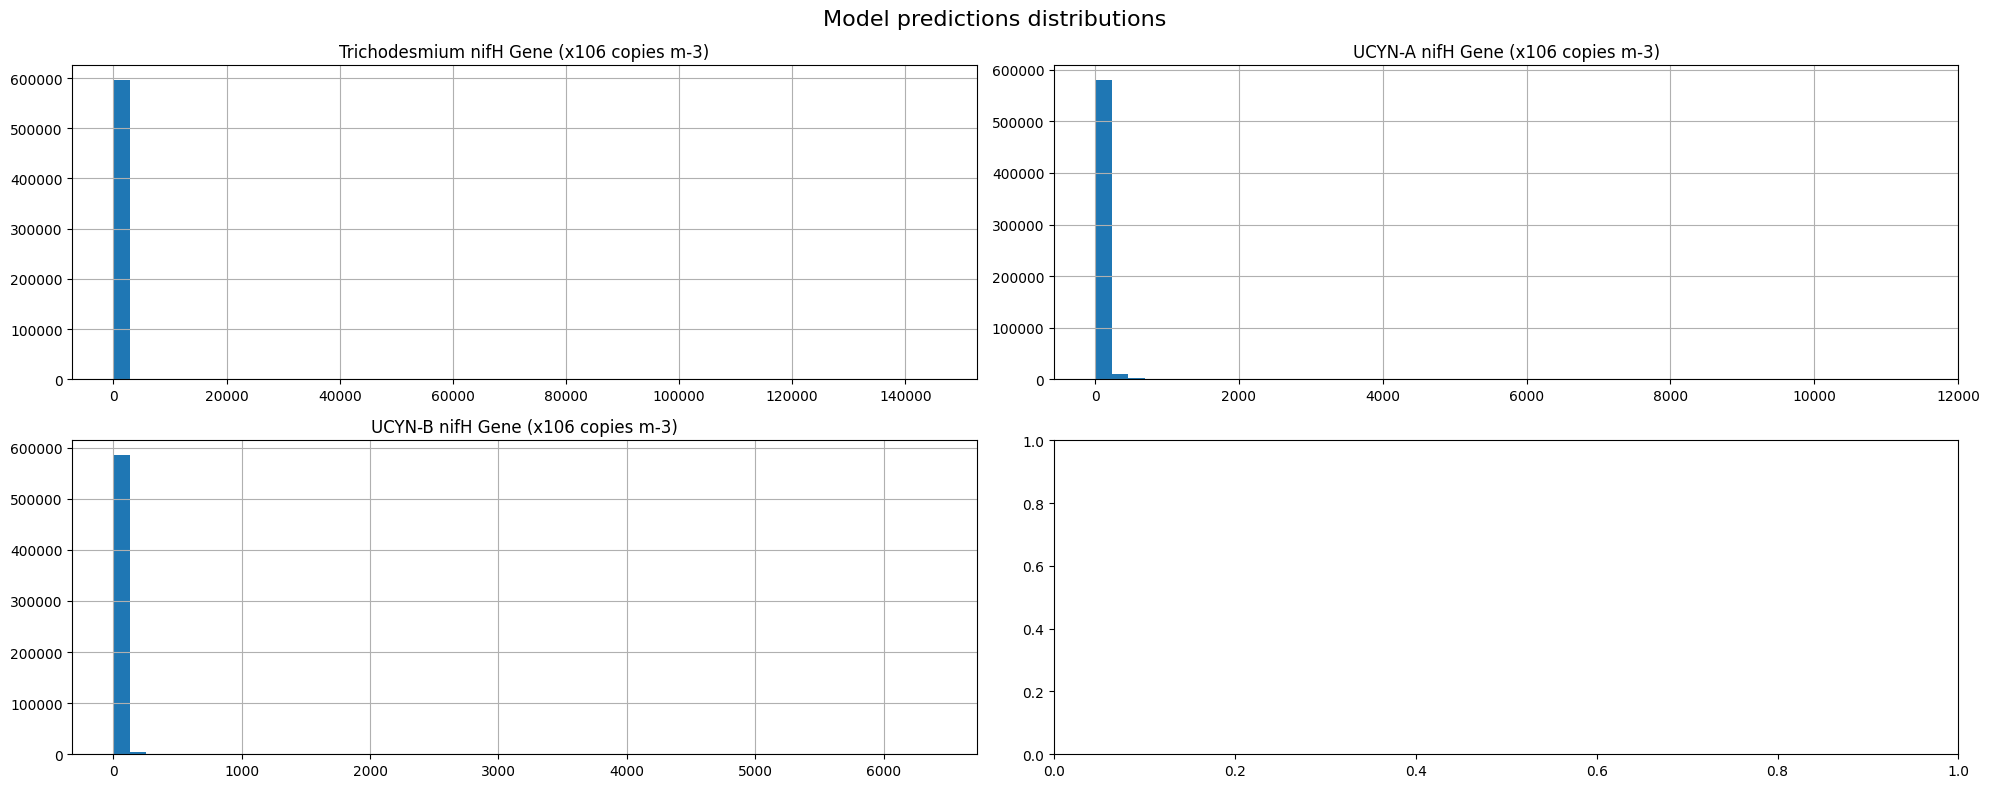

In [38]:
histCols(y_columns, predictions_df_invtr_cr, suptitle="Model predictions distributions")

## Multioutput models

So, one of the key factos of the input and output data is that the correlation between them overall is low, but there is a strong correlation between bacterial data features and between environmental data features. Some models can utilize such properties and might achieve better performance. Thus, I want to try training a model that instead of predicting each feature individually should predict all features at once.

For the dataset I want to use the best perfroming one among already used and for the model the random forest regression.

One issue that should be noted is that not all datapoints are out there such that all 3 variables are not NaN, so perhaps some data should be imputed in order to facilitaty better training.

In [39]:
from sklearn.impute import KNNImputer
dset_name ="simple_transform_nobar"
dataset = datasets[dset_name].copy()

imputer = KNNImputer(n_neighbors=7)
dataset_filled_arr = imputer.fit_transform(dataset)
dataset_filled = pd.DataFrame(dataset_filled_arr, columns=dataset.columns)

dataset_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30615 entries, 0 to 30614
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   O2                                         30615 non-null  float64
 1   T                                          30615 non-null  float64
 2   N                                          30615 non-null  float64
 3   P                                          30615 non-null  float64
 4   Fe                                         30615 non-null  float64
 5   solar                                      30615 non-null  float64
 6   N:P                                        30615 non-null  float64
 7   Trichodesmium nifH Gene (x106 copies m-3)  30615 non-null  float64
 8   UCYN-A nifH Gene (x106 copies m-3)         30615 non-null  float64
 9   UCYN-B nifH Gene (x106 copies m-3)         30615 non-null  float64
dtypes: float64(10)
memory 

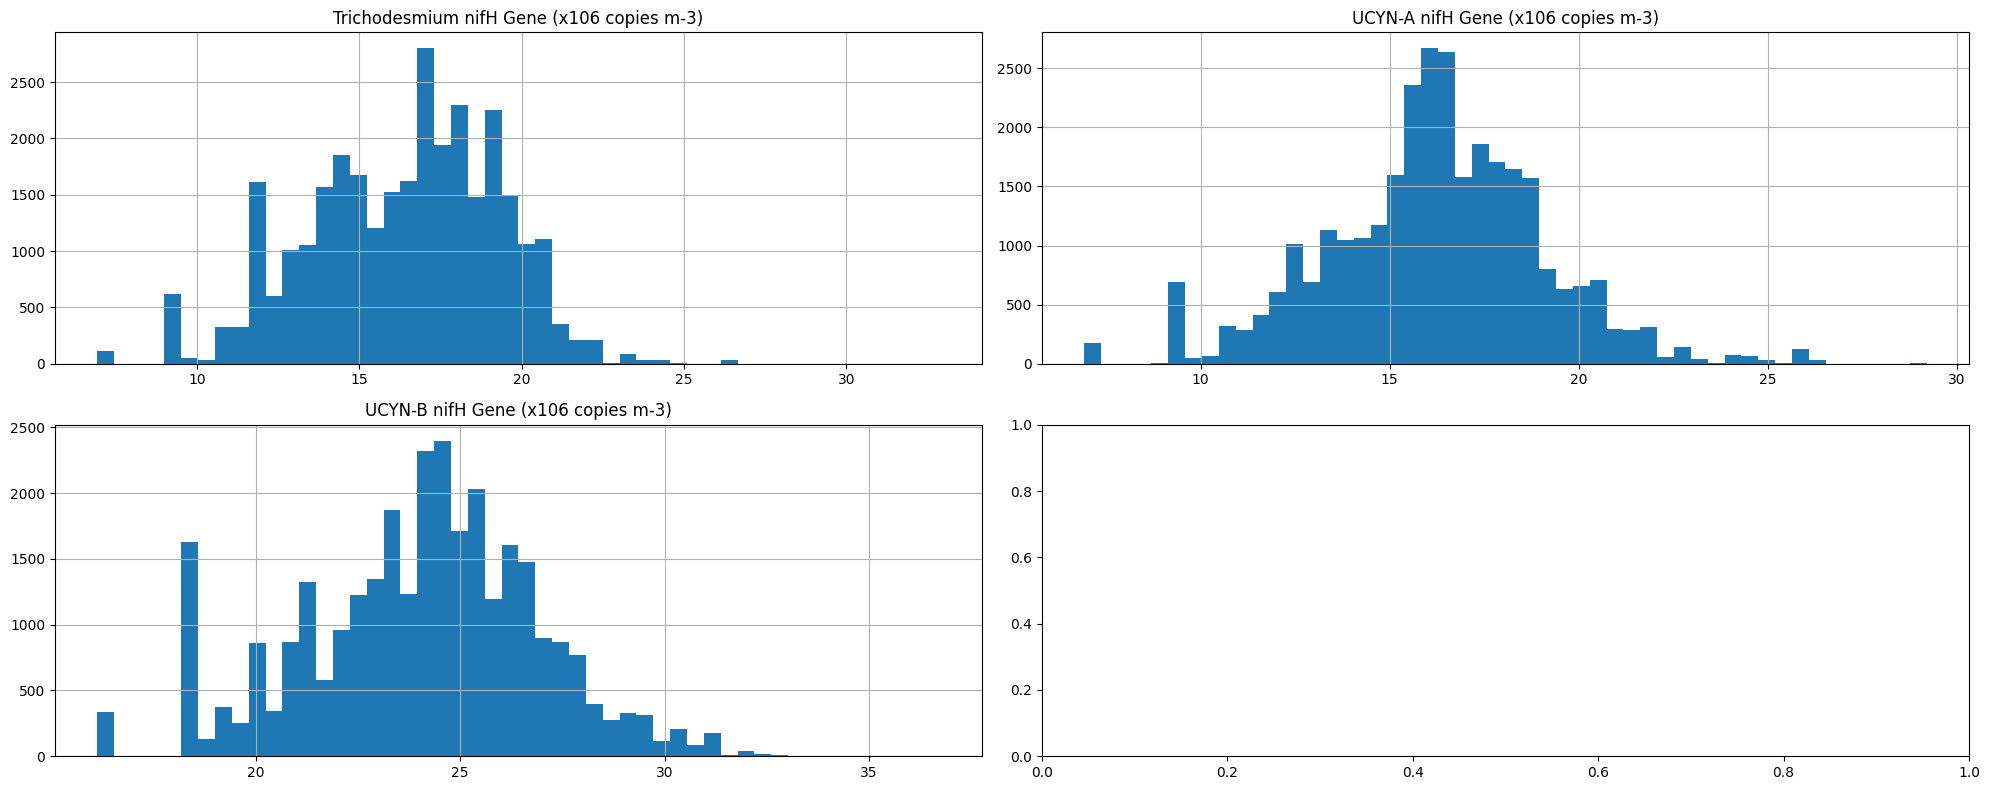

In [40]:
histCols(y_columns, dataset_filled)

### Train test split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(dataset_filled[x_columns], dataset_filled[y_columns], test_size=0.2, random_state=42)

In [42]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

predictions = pd.DataFrame(model.predict(X_test), columns=y_columns)

rsme_scaled = root_mean_squared_error(y_test, predictions)

predictions_inverse_tr = transofrm_back(dset_name, predictions)
y_test_inverse_tr = transofrm_back(dataset_name, y_test)

rsme_unscaled = root_mean_squared_error(y_test_inverse_tr, predictions_inverse_tr)

print("\ndataset: {0}: RSME on scaled dataset: {1}, RSME on unscaled dataset: {2}".format(dset_name, rsme_scaled, rsme_unscaled))

using a simple tr
Simple transformer initiated
using a simple tr
Simple transformer initiated

dataset: simple_transform_nobar: RSME on scaled dataset: 1.3309293436289436, RSME on unscaled dataset: 159807.30538342832


In [43]:
env_data = pd.read_csv("../csv/filled/env_data_lat_fill.csv")
np_ratio = env_data.N/ env_data.P
env_data["N:P"]=np_ratio

coordinates = env_data[["LONGITUDE", "LATITUDE"]].copy()
env_data=env_data[x_columns]

#this is to make sure the scaler works
env_data_rows = env_data.shape[0]
for col in y_columns:
    env_data[col] = np.ones(env_data_rows)

env_data_scaled = transformers[dset_name].transform(env_data)[x_columns]

map_predictions = pd.DataFrame(model.predict(env_data_scaled),columns=y_columns)
map_predictions = transofrm_back(ds_name, map_predictions)
map_predictions = pd.concat([coordinates, map_predictions], axis=1)

map_predictions.describe()

using a simple tr
Simple transformer initiated


,LONGITUDE,LATITUDE,Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06,3.265844e+06
mean,-1.126730e+01,-7.334634e+00,5.827349e+01,3.949811e+01,1.352760e+01
std,1.096526e+02,4.327147e+01,2.152686e+02,2.128030e+02,1.371039e+02
min,-1.800000e+02,-7.800000e+01,1.000000e-03,2.427936e-03,1.000000e-03
25%,-1.140000e+02,-4.400000e+01,1.027782e+01,3.780136e+00,1.618800e+00
50%,-2.000000e+01,-1.200000e+01,3.705915e+01,1.238475e+01,3.458740e+00
75%,8.400000e+01,2.400000e+01,5.541379e+01,2.805398e+01,7.943885e+00
max,1.780000e+02,9.000000e+01,3.834738e+04,1.320714e+05,2.977026e+04


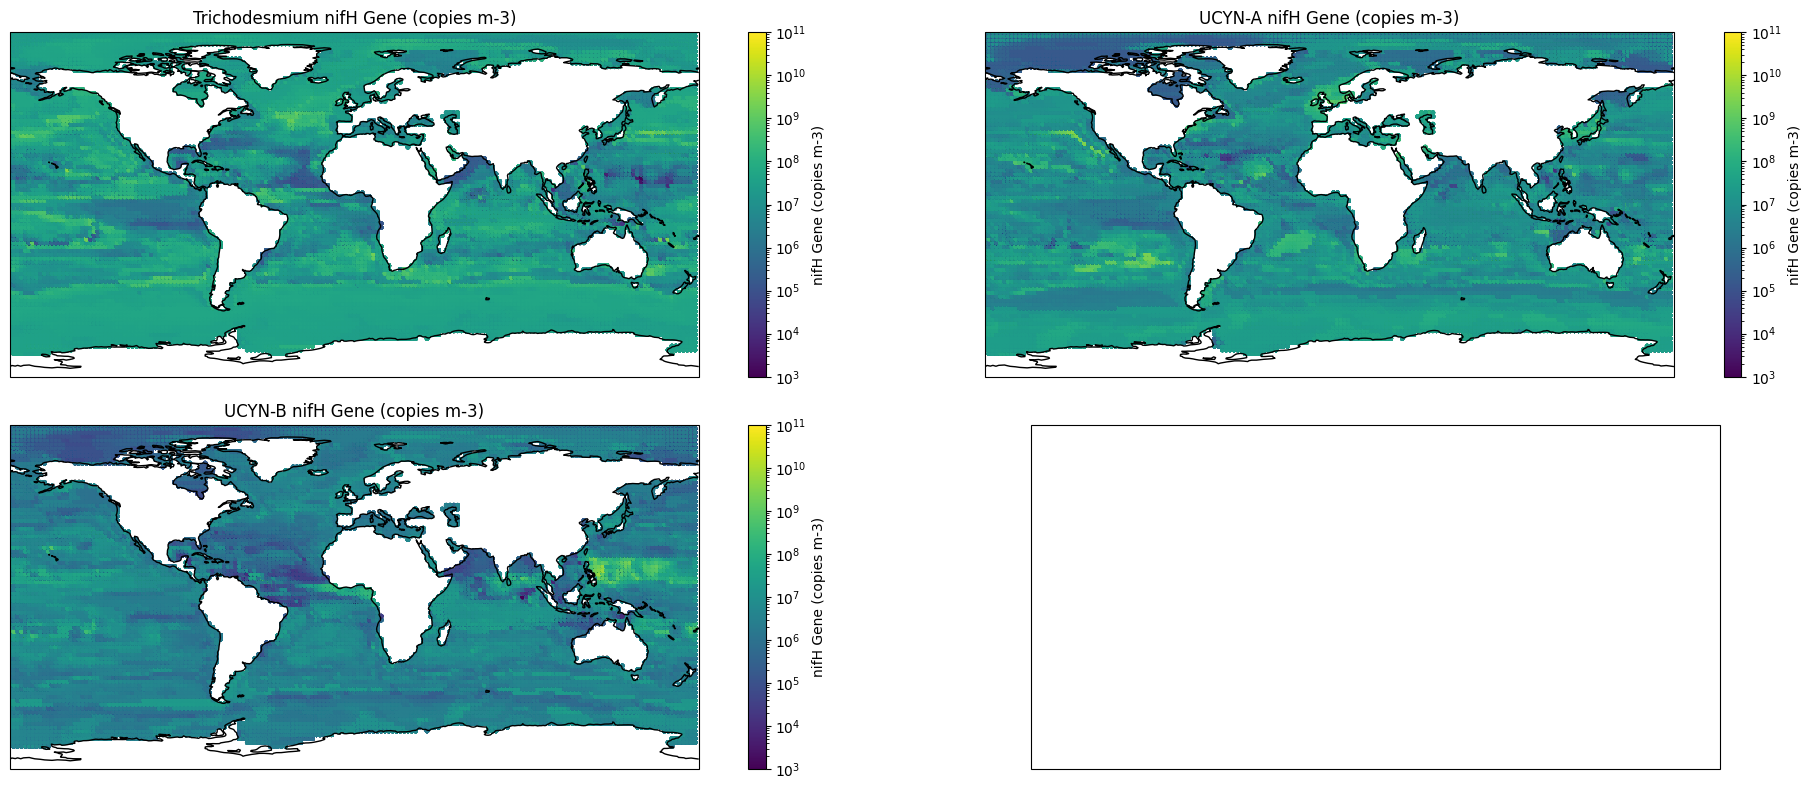

In [44]:
plotColsOnMap(y_columns, map_predictions, True, 10**6)